In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
mosq = pd.read_csv('datasets//dengue.csv')

In [4]:
mosq

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [5]:
mosq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [6]:
mosq.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [7]:
mosq['Year'] = mosq['Year'].astype('int')

In [8]:
mosq.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<h1>Questions and Insights</h1>

<h1>1.Which region had the highest and the lowest average dengue cases across all years?</h1>

In [9]:
region_avg = mosq.groupby('Region')['Dengue_Cases'].mean().sort_values(ascending=False)

In [10]:
region_avg 

Region
Region IV-A    2717.150000
Region III     2184.400000
Region VI      1958.716667
NCR            1932.766667
Region VII     1844.716667
Region X       1373.950000
Region XII      996.700000
Region I        984.433333
Region VIII     866.383333
Region IX       796.350000
Region II       752.350000
Region XIII     588.216667
Region XI       542.033333
Region IV-B     514.150000
CAR             509.700000
Region V        369.450000
BARMM           192.283333
Name: Dengue_Cases, dtype: float64

<h1>Insight1: Based on the result Region IV-A got the highest average of dengue cases across all years.</h1>

<h1>Insight2: The lowest average dengue cases region of all years is BARM with 198.3</h1>

 <h1>2.In what year has the highest dengue death?</h1> 

In [11]:
mosq.groupby('Year')['Dengue_Deaths'].sum()

Year
2016    8127
2017    4563
2018    1226
2019    1733
2020    1195
Name: Dengue_Deaths, dtype: int64

<h1>Insight3:2016 got the highest dengue death based on the data result.</h1>

<h1>3.Which month has the highest total number of dengue deaths overall?</h1>

In [12]:
mosq.groupby('Month')['Dengue_Deaths'].sum().sort_values(ascending=False)

Month
October      6670
September    6148
August        714
November      613
July          611
December      404
January       394
June          322
February      315
March         291
April         200
May           162
Name: Dengue_Deaths, dtype: int64

<h1>Insight4:Based on the result of the data analysis the highest total number of dengue deaths of all the month october with 6,670 total dengue deaths.</h1>

<h1>4.What is the total number of dengue death in NCR region?</h1>

In [13]:
ncr_deaths = mosq[mosq['Region'] == 'NCR']['Dengue_Deaths'].sum()

In [14]:
ncr_deaths

np.int64(4008)

<h1>Insight5:The total number of dengue death in NCR region is 4008.</h1>

<h1>5.What is the average dengue cases per month?</h1>

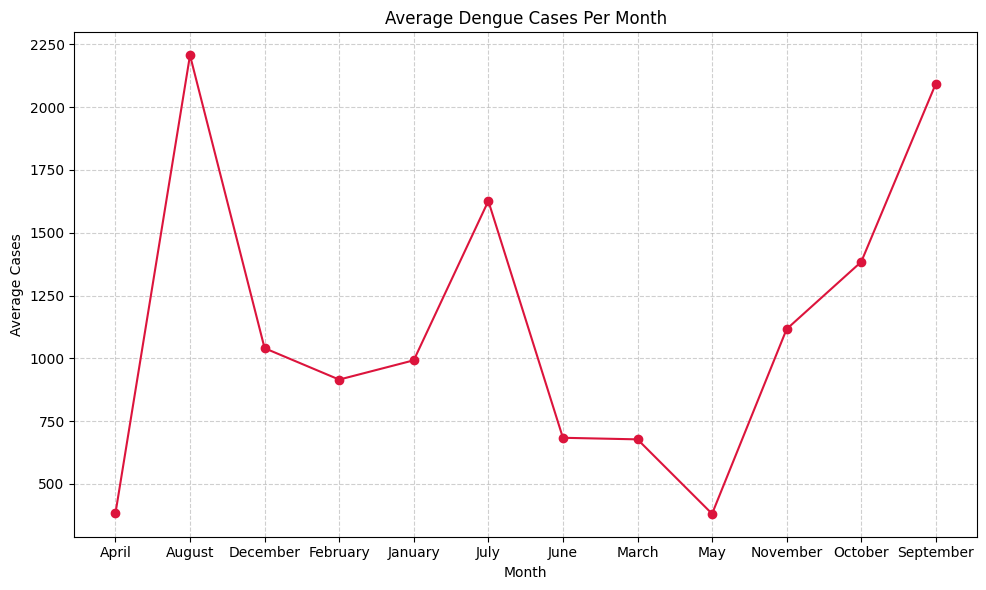

In [15]:
month_avg = mosq.groupby('Month')['Dengue_Cases'].mean()
plt.figure(figsize=(10,6))
plt.plot(month_avg.index, month_avg.values, marker='o', color='Crimson')
plt.title('Average Dengue Cases Per Month')
plt.xlabel('Month')
plt.ylabel('Average Cases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<h1>Insight6:The chart shows that dengue cases are highest in August and September and lowest in April and May.
This means dengue spreads more during the rainy months, when mosquitoes are most active.</h1>

<h1>6.Which regions had the highest number of dengue deaths from 2016 to 2020, and how did their death trends change over the years?</h1>

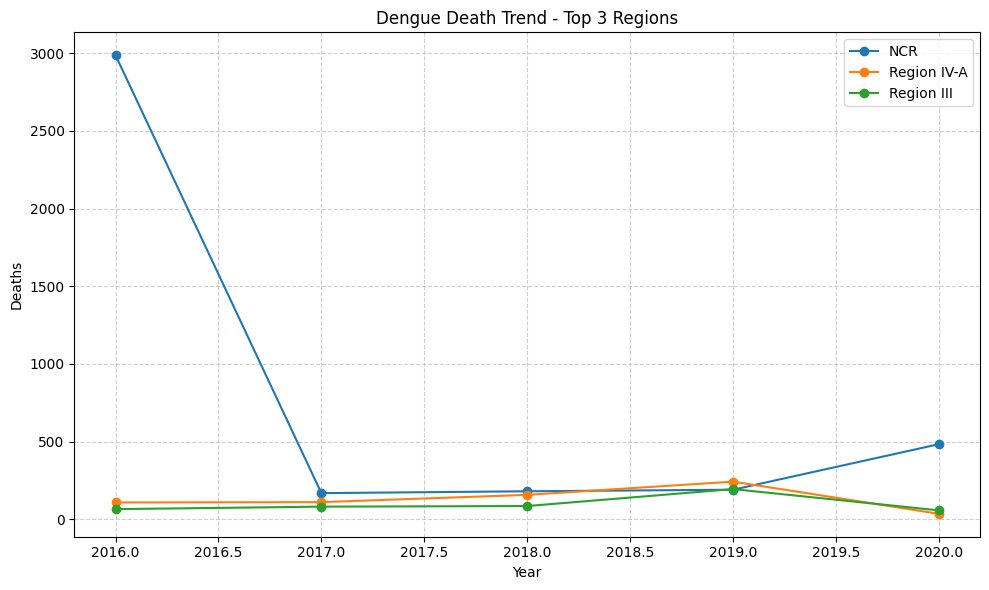

In [16]:
top_regions = ['NCR', 'Region IV-A', 'Region III']
plt.figure(figsize=(10,6))
for region in top_regions:
    trend = mosq[mosq['Region'] == region].groupby('Year')['Dengue_Deaths'].sum()
    plt.plot(trend.index, trend.values, marker='o', label=region)
plt.title('Dengue Death Trend - Top 3 Regions')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<h1>Insight7:NCR had a very high number of deaths in 2016, then the cases dropped a lot in 2017 and slowly went up again by 2020. Regions IV-A and III had fewer deaths, with small increases around 2018–2019.</h1>

<h1>7.Is there a correlation between year and dengue cases?</h1>

In [17]:
mosq[['Year', 'Dengue_Cases']].corr()

,Year,Dengue_Cases
Year,1.000000,0.021167
Dengue_Cases,0.021167,1.000000


<h1>Insight8:There is no significant correlation between the year and the number of dengue cases correlation  0.02 . This means dengue cases did not consistently increase or decrease over the years from 2016 to 2020</h1>

<h1>8.What is the relationship between dengue cases and dengue deaths?</h1>

In [18]:
mosq[['Dengue_Cases', 'Dengue_Deaths']].corr()

,Dengue_Cases,Dengue_Deaths
Dengue_Cases,1.000000,0.038322
Dengue_Deaths,0.038322,1.000000


<h1>Insight9:There is a very weak positive relationship (0.04) between dengue cases and deaths. This means when dengue cases increase, deaths only rise a little, showing no strong connection between them.</h1>

<h1>9.What is the total dengue cases per region for year 2019?</h1>

In [19]:
 mosq[mosq['Year'] == 2019].groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)

Region
Region IV-A    76195
Region VI      60357
NCR            40478
Region III     37158
Region VII     31053
Region X       28356
Region IX      27447
Region VIII    26871
Region XII     20640
Region I       19867
Region II      16634
Region XIII    12054
Region V       11141
Region IV-B    10984
CAR             8808
Region XI       8466
BARMM           5393
Name: Dengue_Cases, dtype: int64

<h1>Insight10:The result shows the total dengue cases per region for year 2019. The region got the highest is Region IV-A followed by Region VI and BARM got the lowest dengue cases.</h1>

<h1>10.What is the average number of dengue cases per month across all regions?</h1>

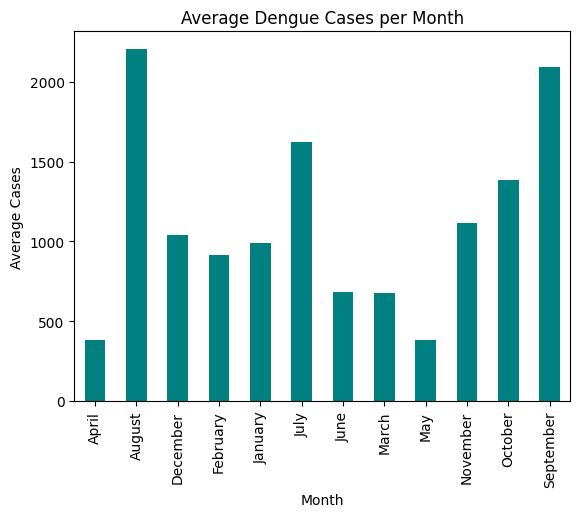

In [20]:
mosq.groupby('Month')['Dengue_Cases'].mean().plot(kind='bar', color='teal')
plt.title('Average Dengue Cases per Month')
plt.xlabel('Month')
plt.ylabel('Average Cases')
plt.show()

<h1>Insight 11:Dengue cases are highest in August and September, which are rainy months. This suggests that dengue spreads more when there is more standing water for mosquitoes to breed</h1>

<h1>Insight 12:The lowest dengue cases are seen in April and May, during the dry season. This shows that weather and rainfall have a big effect on dengue case numbers.|</h1>

<h1>11.What percentage of the total dengue cases occurred in each region from 2016 to 2020?</h1>

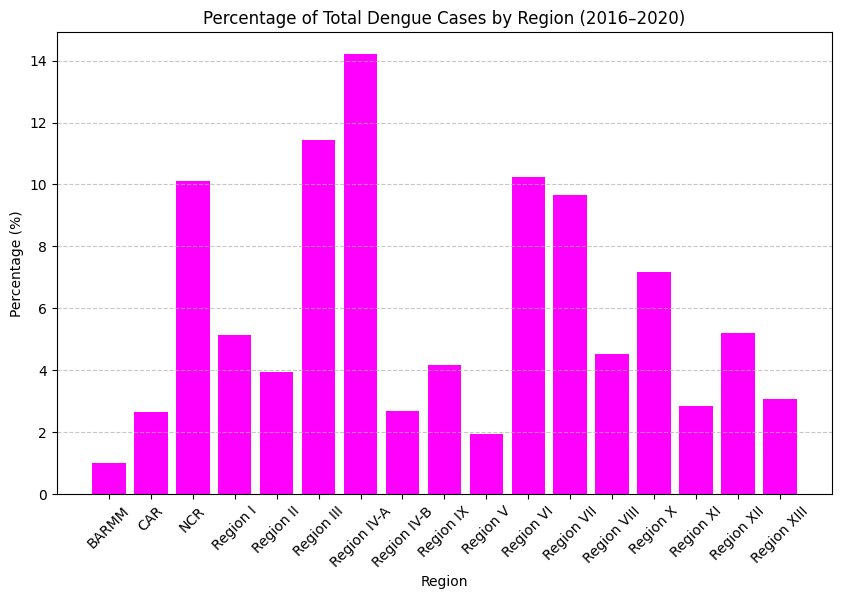

In [24]:
region_cases = mosq.groupby('Region')['Dengue_Cases'].sum()
region_percent = (region_cases / region_cases.sum()) * 100

plt.figure(figsize=(10, 6))
plt.bar(region_percent.index, region_percent, color='magenta')
plt.title('Percentage of Total Dengue Cases by Region (2016–2020)')
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<h1>Insight13:Region IV-A recorded the highest percentage of dengue cases, showing it was one of the most affected areas during 2016–2020. This may be due to its large population and urban centers.</h1>

<h1>Insight14:Regions like BARMM and CAR have the lowest percentages of dengue cases. This suggests these areas might have fewer outbreaks or better mosquito control.</h1>

<h1>Insight15:Most other regions have dengue case percentages between 4% and 10%, showing the disease is spread across the country but affects some regions more severely.</h1>